## Setup

In [ ]:
import os
from dotenv import load_dotenv
import random
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from huggingface_hub import login

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

DATA_DIR       = Path('./data')
TALKDOWN_DIR   = Path('talkdown')
CHECKPOINTS    = Path('checkpoints')
CHECKPOINTS.mkdir(exist_ok=True)

TALKDOWN_CKPT  = CHECKPOINTS / 'deberta_talkdown'
PCL_CKPT       = CHECKPOINTS / 'deberta_pcl_best'

# HF
load_dotenv()  # loads from .env in current directory
HF_TOKEN = os.getenv('HF_TOKEN')
assert HF_TOKEN is not None, '.env file missing or HF_TOKEN not set!'
login(token=HF_TOKEN)
print('HuggingFace authentication successful.')

print('Directories ready.')
print(f'TalkDown checkpoint path : {TALKDOWN_CKPT}')
print(f'PCL checkpoint path      : {PCL_CKPT}')

Device: cuda
GPU: NVIDIA GeForce RTX 4090


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HuggingFace authentication successful.
Directories ready.
TalkDown checkpoint path : checkpoints/deberta_talkdown
PCL checkpoint path      : checkpoints/deberta_pcl_best


## Data loading & Preprocess

In [ ]:
import html, re

def clean_text(text) -> str:
    """Unescape HTML entities and strip residual tags. Handles NaN."""
    if not isinstance(text, str):
        return ''
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', '', text)
    return text.strip()

def add_keyword_prefix(row) -> str:
    """Prepend topic keyword as a bracketed token."""
    return f"[{row['keyword']}] {row['text']}"

df_raw = pd.read_csv(
    DATA_DIR / 'dontpatronizeme_pcl.tsv', sep='\t', header=None,
    names=['par_id','art_id','keyword','country','text','label']
)

# Drop disclaimer / separator rows
df_raw = df_raw[pd.to_numeric(df_raw['par_id'], errors='coerce').notna()].copy()
df_raw['par_id'] = df_raw['par_id'].astype(int)

train_ids = pd.read_csv(DATA_DIR / 'train_semeval_parids-labels.csv')
dev_ids   = pd.read_csv(DATA_DIR / 'dev_semeval_parids-labels.csv')

train = df_raw[df_raw['par_id'].isin(train_ids['par_id'])].copy()
dev   = df_raw[df_raw['par_id'].isin(dev_ids['par_id'])].copy()

# Binarise labels (0-4 scale -> 0/1)
train['label'] = (train['label'].astype(int) >= 1).astype(int)
dev['label']   = (dev['label'].astype(int) >= 1).astype(int)

# Clean text
train['text'] = train['text'].apply(clean_text)
dev['text']   = dev['text'].apply(clean_text)

# Add keyword prefix
train['text_input'] = train.apply(add_keyword_prefix, axis=1)
dev['text_input']   = dev.apply(add_keyword_prefix, axis=1)

# Sanity checks
print(f'Train size : {len(train)}')
print(f'Dev size   : {len(dev)}')
print(f'Train label distribution:\n{train["label"].value_counts()}')
print(f'Dev label distribution:\n{dev["label"].value_counts()}')
print(f'\nSample input (train[0]):')
print(train['text_input'].iloc[0])
assert train['text'].isna().sum() == 0, 'NaN texts in train!'
assert dev['text'].isna().sum() == 0,   'NaN texts in dev!'
assert set(train['label'].unique()) == {0, 1}, 'Labels not binarised!'
print('\nAll sanity checks passed.')

Train size : 8375
Dev size   : 2094
Train label distribution:
label
0    6825
1    1550
Name: count, dtype: int64
Dev label distribution:
label
0    1704
1     390
Name: count, dtype: int64

Sample input (train[0]):
[hopeless] We 're living in times of absolute insanity , as I 'm pretty sure most people are aware . For a while , waking up every day to check the news seemed to carry with it the same feeling of panic and dread that action heroes probably face when they 're trying to decide whether to cut the blue or green wire on a ticking bomb -- except the bomb 's instructions long ago burned in a fire and imminent catastrophe seems the likeliest outcome . It 's hard to stay that on-edge for that long , though , so it 's natural for people to become inured to this constant chaos , to slump into a malaise of hopelessness and pessimism .

All sanity checks passed.


In [3]:
test = pd.read_csv(
    DATA_DIR / 'task4_test.tsv', sep='\t', header=None,
    names=['par_id', 'art_id', 'keyword', 'country', 'text']
)

# No disclaimer rows to filter — IDs are already clean (t_0, t_1, ...)
test['text'] = test['text'].apply(clean_text)
test['text_input'] = test.apply(add_keyword_prefix, axis=1)

print(f'Test size: {len(test)}')
print(f'Sample test input: {test["text_input"].iloc[0]}')
assert len(test) == 3832, f'Expected 3832 test rows, got {len(test)}'
assert test['text'].isna().sum() == 0, 'NaN texts in test!'
print('Test set loaded successfully.')

Test size: 3832
Sample test input: [vulnerable] In the meantime , conservatives are working to weaken Clinton and drive down her numbers in early voting states , where she is increasingly vulnerable . They are , in effect , doing Sanders 's dirty work for him while he avoids scrutiny .
Test set loaded successfully.


## Talkdown dataset

In [ ]:
import urllib.request
import tarfile

# Download and extract TalkDown dataset
TALKDOWN_URL = 'https://cs.stanford.edu/people/zijwang/talkdown/talkdown.tar.gz'
TALKDOWN_TAR = Path('talkdown.tar.gz')

# Skip if already downloaded
if (TALKDOWN_DIR / 'balanced_train.jsonl').exists():
    print('TalkDown already extracted — skipping download.')
else:
    TALKDOWN_DIR.mkdir(exist_ok=True)

    # Download
    print(f'Downloading TalkDown from {TALKDOWN_URL}...')
    urllib.request.urlretrieve(TALKDOWN_URL, TALKDOWN_TAR)
    print(f'Downloaded: {TALKDOWN_TAR} ({TALKDOWN_TAR.stat().st_size / 1e6:.1f} MB)')

    # Extract
    print('Extracting...')
    with tarfile.open(TALKDOWN_TAR, 'r:gz') as tar:
        tar.extractall(path=TALKDOWN_DIR)
    print(f'Extracted to {TALKDOWN_DIR}/')

    # Clean up tar file
    TALKDOWN_TAR.unlink()
    print('Removed tar file.')

    # Verify
    expected = ['balanced_train.jsonl', 'balanced_dev.jsonl', 'balanced_test.jsonl']
    for f in expected:
        # Search recursively in case tar extracted into a subdirectory
        matches = list(TALKDOWN_DIR.rglob(f))
        assert len(matches) > 0, f'{f} not found after extraction!'
        print(f'  ✓ {matches[0]}')

    print('TalkDown download and extraction complete.')

# Move files to talkdown/ root if extracted into subdirectory
import shutil
for jsonl in TALKDOWN_DIR.rglob('*.jsonl'):
    target = TALKDOWN_DIR / jsonl.name
    if jsonl != target:
        shutil.move(str(jsonl), str(target))
        print(f'Moved {jsonl.name} to {target}')

print(f'Files in {TALKDOWN_DIR}/:')
for f in sorted(TALKDOWN_DIR.iterdir()):
    print(f'  {f.name}')

TalkDown already extracted — skipping download.
Files in talkdown/:
  README.md
  annotated.jsonl
  balanced_dev.jsonl
  balanced_test.jsonl
  balanced_train.jsonl
  imbalanced_dev.jsonl
  imbalanced_test.jsonl
  imbalanced_train.jsonl


In [ ]:
import json

def load_jsonl(path):
    records = []
    with open(path, 'r') as f:
        for line in f:
            records.append(json.loads(line.strip()))
    return pd.DataFrame(records)

# assert files exist
assert (TALKDOWN_DIR / 'balanced_train.jsonl').exists(), 'TalkDown train file not found!'
assert (TALKDOWN_DIR / 'balanced_dev.jsonl').exists(), 'TalkDown dev file not found!'

td_train = load_jsonl(TALKDOWN_DIR / 'balanced_train.jsonl')
td_val   = load_jsonl(TALKDOWN_DIR / 'balanced_dev.jsonl')

# 'post' as text, convert bool label to int
td_train['text']  = td_train['post'].apply(clean_text)
td_train['label'] = td_train['label'].astype(int)
td_val['text']    = td_val['post'].apply(clean_text)
td_val['label']   = td_val['label'].astype(int)

td_train = td_train.dropna(subset=['text']).reset_index(drop=True)
td_val   = td_val.dropna(subset=['text']).reset_index(drop=True)

print(f'TalkDown train: {len(td_train)} | val: {len(td_val)}')
print(f'Label distribution:\n{td_train["label"].value_counts()}')
print(f'Sample: {td_train["text"].iloc[0][:100]}')

TalkDown train: 5208 | val: 650
Label distribution:
label
1    2604
0    2604
Name: count, dtype: int64
Sample: Well a guy is saying Barra, who has those great credentials, sucks... It is just so rude an misinfor


## Tokeniser & classes

In [ ]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader

MODEL_NAME = 'microsoft/deberta-v3-base'
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TextDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_length=256):
        self.texts      = texts.tolist() if hasattr(texts, 'tolist') else list(texts)
        self.labels     = labels.tolist() if labels is not None else None
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation    = True,
            max_length    = self.max_length,
            padding       = 'max_length',
            return_tensors= 'pt'
        )
        item = {
            'input_ids'     : encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
        }
        if 'token_type_ids' in encoding:
            item['token_type_ids'] = encoding['token_type_ids'].squeeze()
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# Sanity check tokeniser
sample = tokenizer(
    '[homeless] This is a test sentence.',
    truncation=True, max_length=MAX_LENGTH, return_tensors='pt'
)
print(f'Tokeniser loaded: {MODEL_NAME}')
print(f'Sample token count: {sample["input_ids"].shape[1]}')
print('Tokeniser sanity check passed.')

Tokeniser loaded: microsoft/deberta-v3-base
Sample token count: 10
Tokeniser sanity check passed.


## Utilities

In [ ]:
import json
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.amp import GradScaler, autocast
from sklearn.metrics import f1_score, classification_report

# GPU optimisations for 4090
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True

def compute_f1(preds, labels, positive_label=1):
    return f1_score(labels, preds, pos_label=positive_label)

def evaluate(model, dataloader, device):
    """Returns F1 on positive class, all predictions, and all labels."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in dataloader:
            input_ids      = batch['input_ids'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            labels         = batch['labels'].to(device, non_blocking=True)
            kwargs = {'input_ids': input_ids, 'attention_mask': attention_mask}
            if 'token_type_ids' in batch:
                kwargs['token_type_ids'] = batch['token_type_ids'].to(device, non_blocking=True)
            with autocast(device_type='cuda'):
                outputs = model(**kwargs)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    f1 = compute_f1(all_preds, all_labels)
    return f1, all_preds, all_labels

def save_training_metadata(save_path, epoch, best_f1):
    Path(save_path).mkdir(parents=True, exist_ok=True)
    meta = {'epochs_completed': epoch, 'best_f1': best_f1}
    with open(Path(save_path) / 'training_meta.json', 'w') as f:
        json.dump(meta, f)

def load_training_metadata(save_path):
    meta_path = Path(save_path) / 'training_meta.json'
    if meta_path.exists():
        with open(meta_path) as f:
            return json.load(f)
    return None

def train_model(
    model, train_loader, val_loader,
    n_epochs, lr, warmup_steps,
    device, save_path,
    class_weights=None,
    use_amp=True,
    gradient_accumulation_steps=1,
    resume_from_checkpoint=False
):
    # Checkpoint handling
    if Path(save_path).exists() and not resume_from_checkpoint:
        print(f'Checkpoint found at {save_path} — loading saved model, skipping training.')
        model = AutoModelForSequenceClassification.from_pretrained(save_path)
        model.to(device)
        return model

    start_epoch = 0

    if Path(save_path).exists() and resume_from_checkpoint:
        print(f'Resuming training from checkpoint: {save_path}')
        model = AutoModelForSequenceClassification.from_pretrained(save_path)
        model.to(device)
        meta = load_training_metadata(save_path)
        if meta is not None:
            start_epoch = meta['epochs_completed']
            best_f1     = meta['best_f1']
            print(f'Epochs already completed : {start_epoch}')
            print(f'Checkpoint val F1        : {best_f1:.4f}')
            if start_epoch >= n_epochs:
                print(f'Already completed {start_epoch} epochs — target is {n_epochs}. Nothing to do.')
                print('Increase NUM_EPOCHS to train further.')
                return model
            print(f'Resuming from epoch {start_epoch + 1} to {n_epochs} ({n_epochs - start_epoch} epochs remaining).')
        else:
            best_f1, _, _ = evaluate(model, val_loader, device)
            print(f'No metadata found. Checkpoint val F1: {best_f1:.4f}')
    else:
        print('No checkpoint found — starting training from scratch.')
        best_f1     = 0.0
        start_epoch = 0
        model.to(device)

    #  Loss: class-weighted cross-entropy
    if class_weights is not None:
        weights = torch.tensor(class_weights, dtype=torch.float).to(device)
        loss_fn = torch.nn.CrossEntropyLoss(weight=weights)
    else:
        loss_fn = torch.nn.CrossEntropyLoss()
    print(f'Loss: CrossEntropyLoss(class_weights={class_weights})')

    remaining_steps = len(train_loader) * (n_epochs - start_epoch)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps   = warmup_steps,
        num_training_steps = remaining_steps
    )
    scaler = GradScaler('cuda') if use_amp else None

    for epoch in range(start_epoch, n_epochs):
        model.train()
        total_loss = 0
        optimizer.zero_grad()

        for step, batch in enumerate(train_loader):
            input_ids      = batch['input_ids'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            labels         = batch['labels'].to(device, non_blocking=True)
            kwargs = {'input_ids': input_ids, 'attention_mask': attention_mask}
            if 'token_type_ids' in batch:
                kwargs['token_type_ids'] = batch['token_type_ids'].to(device, non_blocking=True)

            if use_amp:
                with autocast(device_type='cuda', enabled=use_amp):
                    outputs = model(**kwargs)
                    loss    = loss_fn(outputs.logits, labels)
                loss = loss / gradient_accumulation_steps
                scaler.scale(loss).backward()
                if (step + 1) % gradient_accumulation_steps == 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    scheduler.step()
                    optimizer.zero_grad()
            else:
                outputs = model(**kwargs)
                loss    = loss_fn(outputs.logits, labels)
                loss    = loss / gradient_accumulation_steps
                loss.backward()
                if (step + 1) % gradient_accumulation_steps == 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad()

            total_loss += loss.item() * gradient_accumulation_steps
            if step % 50 == 0:
                print(f'  Epoch {epoch+1} | Step {step}/{len(train_loader)} | Loss: {loss.item()*gradient_accumulation_steps:.4f}')

        avg_loss = total_loss / len(train_loader)
        val_f1, _, _ = evaluate(model, val_loader, device)
        print(f'Epoch {epoch+1}/{n_epochs} | Avg Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f}')

        if val_f1 > best_f1:
            best_f1 = val_f1
            save_model = model._orig_mod if hasattr(model, '_orig_mod') else model
            save_model.save_pretrained(save_path)
            tokenizer.save_pretrained(save_path)
            print(f'  ✓ New best model saved (F1={best_f1:.4f})')

        # save metadata once per epoch
        save_training_metadata(save_path, epoch + 1, best_f1)

    print(f'Training complete. Best val F1: {best_f1:.4f}')
    return model
print('Training utilities loaded.')

Training utilities loaded.


## Stage 1: fine tune on TalkDown

In [ ]:
if not (TALKDOWN_DIR / 'balanced_train.jsonl').exists():
    print('TalkDown dataset not found — skipping Stage 1.')
elif TALKDOWN_CKPT.exists():
    print(f'TalkDown checkpoint found — loading saved model, skipping training.')
    td_model = AutoModelForSequenceClassification.from_pretrained(
        TALKDOWN_CKPT,
        num_labels=2,
        dtype=torch.float32
    )
    td_model.to(DEVICE)
    print(f'Stage 1 complete. Loaded from: {TALKDOWN_CKPT}')
else:
    # clear GPU memory
    import gc
    gc.collect()
    torch.cuda.empty_cache()
    # Filter out empty/null texts
    td_train = td_train[td_train['text'].str.strip().str.len() > 5].reset_index(drop=True)
    td_val   = td_val[td_val['text'].str.strip().str.len() > 5].reset_index(drop=True)
    print(f'TalkDown train after filtering: {len(td_train)}')
    print(f'TalkDown val after filtering  : {len(td_val)}')
    # check for nan
    assert td_train['label'].isna().sum() == 0, 'NaN labels in TalkDown train!'
    assert set(td_train['label'].unique()).issubset({0, 1}), f'Unexpected labels: {td_train["label"].unique()}'
    print(f'Label distribution:\n{td_train["label"].value_counts()}')
    BATCH_SIZE_TD = 8
    td_train_dataset = TextDataset(td_train['text'], td_train['label'], tokenizer, MAX_LENGTH)
    td_val_dataset   = TextDataset(td_val['text'],   td_val['label'],   tokenizer, MAX_LENGTH)
    td_train_loader  = DataLoader(td_train_dataset, batch_size=BATCH_SIZE_TD, shuffle=True, drop_last=True)
    td_val_loader    = DataLoader(td_val_dataset,   batch_size=BATCH_SIZE_TD, drop_last=False)

    sample_batch = next(iter(td_train_loader))
    print(f'Batch input_ids shape : {sample_batch["input_ids"].shape}')
    print(f'Batch labels          : {sample_batch["labels"][:8]}')
    assert not torch.isnan(sample_batch['input_ids'].float()).any(), 'NaN in input_ids!'
    # fresh deberta
    td_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2, dtype=torch.float32
    )
    for name, param in td_model.named_parameters():
        if torch.isnan(param).any():
            print(f'NaN in parameter: {name}')
            break
    else:
        print('Model parameters clean — no NaN detected.')
    print('Starting Stage 1: TalkDown fine-tuning...')
    td_model = train_model(
        model         = td_model,
        train_loader  = td_train_loader,
        val_loader    = td_val_loader,
        n_epochs      = 3,
        lr            = 5e-6,
        warmup_steps  = 200,
        device        = DEVICE,
        save_path     = TALKDOWN_CKPT,
        class_weights = None
    )
    assert TALKDOWN_CKPT.exists(), 'TalkDown checkpoint not saved!'
    print(f'Stage 1 complete. Checkpoint: {TALKDOWN_CKPT}')

TalkDown checkpoint found — loading saved model, skipping training.


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Stage 1 complete. Loaded from: checkpoints/deberta_talkdown


## Fine-tune on PCL

In [ ]:
from torch.utils.data import WeightedRandomSampler
from torch.amp import GradScaler, autocast

# gpu optimisations
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True

BATCH_SIZE_PCL = 32   # maximize for 4090 24GB
NUM_WORKERS    = 4
NUM_EPOCHS     = 10    # more epochs for PCL fine-tuning, best ckpt auto-saved

# ── Class weights (4.4:1 imbalance) ──────────────────────────────────────────
n_neg     = (train['label'] == 0).sum()
n_pos     = (train['label'] == 1).sum()
w_neg     = 1.0
w_pos     = n_neg / n_pos
CLASS_WEIGHTS = [w_neg, w_pos]
print(f'Class weights: No PCL={w_neg:.2f}, PCL={w_pos:.2f}')

train_dataset = TextDataset(train['text_input'], train['label'], tokenizer, MAX_LENGTH)
dev_dataset   = TextDataset(dev['text_input'],   dev['label'],   tokenizer, MAX_LENGTH)

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE_PCL,
    shuffle     = True,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
    prefetch_factor  = 2,     # prefetch 2 batches per worker
    persistent_workers = True # keep workers alive between epochs
)
dev_loader = DataLoader(
    dev_dataset,
    batch_size  = BATCH_SIZE_PCL * 2,
    num_workers = NUM_WORKERS,
    pin_memory  = True,
    prefetch_factor  = 2,
    persistent_workers = True
)

# sanity check
sample_batch = next(iter(train_loader))
print(f'PCL batch input_ids shape : {sample_batch["input_ids"].shape}')
print(f'PCL batch labels (first 8): {sample_batch["labels"][:8]}')
assert sample_batch['input_ids'].shape[1] == MAX_LENGTH, 'Wrong max_length!'

# load from checkpoint or use fresh deberta
if TALKDOWN_CKPT.exists():
    print(f'Loading TalkDown checkpoint from {TALKDOWN_CKPT}')
    pcl_model = AutoModelForSequenceClassification.from_pretrained(
        TALKDOWN_CKPT, num_labels=2,
        ignore_mismatched_sizes=True,
        torch_dtype=torch.float32
    )
else:
    print('No TalkDown checkpoint found — loading fresh DeBERTa.')
    pcl_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2, torch_dtype=torch.float32
    )
    
print('Compiling model with torch.compile...')
pcl_model = torch.compile(pcl_model, mode='reduce-overhead')
print('Model compiled.')

print('Starting Stage 2: PCL fine-tuning...')
pcl_model = train_model(
    model         = pcl_model,
    train_loader  = train_loader,
    val_loader    = dev_loader,
    n_epochs      = NUM_EPOCHS,
    lr            = 2e-5,    # slightly higher LR suits larger batch
    warmup_steps  = 150,
    device        = DEVICE,
    save_path     = PCL_CKPT,
    class_weights = CLASS_WEIGHTS,
    use_amp       = True,    # mixed precision — faster on 4090,
    resume_from_checkpoint=False # resume training from checkpoint
)

assert PCL_CKPT.exists(), 'PCL checkpoint not saved!'
print(f'Stage 2 complete. Checkpoint: {PCL_CKPT}')

Class weights: No PCL=1.00, PCL=4.40
PCL batch input_ids shape : torch.Size([32, 256])
PCL batch labels (first 8): tensor([0, 0, 1, 1, 0, 0, 0, 0])
Loading TalkDown checkpoint from checkpoints/deberta_talkdown


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Compiling model with torch.compile...
Model compiled.
Starting Stage 2: PCL fine-tuning...
No checkpoint found — starting training from scratch.
Loss: CrossEntropyLoss(class_weights=[1.0, np.float64(4.403225806451613)])
  Epoch 1 | Step 0/262 | Loss: 0.7110
  Epoch 1 | Step 50/262 | Loss: 0.6000
  Epoch 1 | Step 100/262 | Loss: 0.6651
  Epoch 1 | Step 150/262 | Loss: 0.7115
  Epoch 1 | Step 200/262 | Loss: 0.4802
  Epoch 1 | Step 250/262 | Loss: 0.5505
Epoch 1/16 | Avg Loss: 0.6271 | Val F1: 0.4961


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (F1=0.4961)
  Epoch 2 | Step 0/262 | Loss: 0.4817
  Epoch 2 | Step 50/262 | Loss: 0.7604
  Epoch 2 | Step 100/262 | Loss: 0.5150
  Epoch 2 | Step 150/262 | Loss: 0.3124
  Epoch 2 | Step 200/262 | Loss: 0.6454
  Epoch 2 | Step 250/262 | Loss: 0.4520
Epoch 2/16 | Avg Loss: 0.5190 | Val F1: 0.5745


...

  ✓ New best model saved (F1=0.5976)
  Epoch 6 | Step 0/262 | Loss: 0.1478
  Epoch 6 | Step 50/262 | Loss: 0.5791
  Epoch 6 | Step 100/262 | Loss: 0.2103
  Epoch 6 | Step 150/262 | Loss: 0.3660
  Epoch 6 | Step 200/262 | Loss: 0.2227
  Epoch 6 | Step 250/262 | Loss: 0.2060
Epoch 6/16 | Avg Loss: 0.2681 | Val F1: 0.6083


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (F1=0.6083)
  Epoch 7 | Step 0/262 | Loss: 0.1665
  Epoch 7 | Step 50/262 | Loss: 0.0900
  Epoch 7 | Step 100/262 | Loss: 0.1089
  Epoch 7 | Step 150/262 | Loss: 0.7183
  Epoch 7 | Step 200/262 | Loss: 0.1693
  Epoch 7 | Step 250/262 | Loss: 0.0703
Epoch 7/16 | Avg Loss: 0.2267 | Val F1: 0.5857
  Epoch 8 | Step 0/262 | Loss: 0.0750
  Epoch 8 | Step 50/262 | Loss: 0.0189
  Epoch 8 | Step 100/262 | Loss: 0.2195
  Epoch 8 | Step 150/262 | Loss: 0.1336
  Epoch 8 | Step 200/262 | Loss: 0.0540
  Epoch 8 | Step 250/262 | Loss: 0.5009
Epoch 8/16 | Avg Loss: 0.1811 | Val F1: 0.6064
  Epoch 9 | Step 0/262 | Loss: 0.0722
  Epoch 9 | Step 50/262 | Loss: 0.1640
  Epoch 9 | Step 100/262 | Loss: 0.0151
  Epoch 9 | Step 150/262 | Loss: 0.3208
  Epoch 9 | Step 200/262 | Loss: 0.3738
  Epoch 9 | Step 250/262 | Loss: 0.0199
Epoch 9/16 | Avg Loss: 0.1590 | Val F1: 0.5833
  Epoch 10 | Step 0/262 | Loss: 0.1756
  Epoch 10 | Step 50/262 | Loss: 0.0845
  Epoch 10 | Step 100/262 | Loss

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (F1=0.6130)
  Epoch 11 | Step 0/262 | Loss: 0.0099
  Epoch 11 | Step 50/262 | Loss: 0.0272
  Epoch 11 | Step 100/262 | Loss: 0.0055
  Epoch 11 | Step 150/262 | Loss: 0.1150
  Epoch 11 | Step 200/262 | Loss: 0.3629
  Epoch 11 | Step 250/262 | Loss: 0.0052
Epoch 11/16 | Avg Loss: 0.1122 | Val F1: 0.6069
  Epoch 12 | Step 0/262 | Loss: 0.0987
  Epoch 12 | Step 50/262 | Loss: 0.0048
  Epoch 12 | Step 100/262 | Loss: 0.0928
  Epoch 12 | Step 150/262 | Loss: 0.0054
  Epoch 12 | Step 200/262 | Loss: 0.0149
  Epoch 12 | Step 250/262 | Loss: 0.0749
Epoch 12/16 | Avg Loss: 0.0936 | Val F1: 0.5795
  Epoch 13 | Step 0/262 | Loss: 0.4676
  Epoch 13 | Step 50/262 | Loss: 0.0049
  Epoch 13 | Step 100/262 | Loss: 0.0156
  Epoch 13 | Step 150/262 | Loss: 0.0827
  Epoch 13 | Step 200/262 | Loss: 0.0041
  Epoch 13 | Step 250/262 | Loss: 0.0057
Epoch 13/16 | Avg Loss: 0.0737 | Val F1: 0.5861
  Epoch 14 | Step 0/262 | Loss: 0.0073
  Epoch 14 | Step 50/262 | Loss: 0.5138
  Epoch 14 

## load best model and eval on dev set

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

best_model = AutoModelForSequenceClassification.from_pretrained(PCL_CKPT)
best_model.to(DEVICE)
print(f'Loaded best model from {PCL_CKPT}')

dev_f1, dev_preds, dev_labels = evaluate(best_model, dev_loader, DEVICE)

print(f'\n=== DEV SET EVALUATION ===')
print(f'F1 (PCL class): {dev_f1:.4f}')
print(f'Baseline F1   : 0.48')
print(f'Delta         : {dev_f1 - 0.48:+.4f}')
print(f'\n=== CLASSIFICATION REPORT ===')
print(classification_report(dev_labels, dev_preds, target_names=['No PCL', 'PCL']))
print(f'\n=== CONFUSION MATRIX ===')
print(confusion_matrix(dev_labels, dev_preds))

assert len(dev_preds) == len(dev), f'Prediction count mismatch: {len(dev_preds)} vs {len(dev)}'
assert set(dev_preds).issubset({0, 1}), 'Predictions contain values other than 0 and 1!'
print('\nEvaluation sanity checks passed.')

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Loaded best model from checkpoints/deberta_pcl_best

=== DEV SET EVALUATION ===
F1 (PCL class): 0.6137
Baseline F1   : 0.48
Delta         : +0.1337

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      No PCL       0.93      0.86      0.89      1704
         PCL       0.54      0.71      0.61       390

    accuracy                           0.83      2094
   macro avg       0.73      0.79      0.75      2094
weighted avg       0.86      0.83      0.84      2094


=== CONFUSION MATRIX ===
[[1466  238]
 [ 112  278]]

Evaluation sanity checks passed.


### Threshold tuning

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

best_model = AutoModelForSequenceClassification.from_pretrained(PCL_CKPT)
best_model.to(DEVICE)
best_model.eval()
print(f'Loaded best model from {PCL_CKPT}')

# Get raw probabilities
all_probs  = []
all_labels = []

with torch.no_grad():
    for batch in dev_loader:
        outputs = best_model(
            input_ids      = batch['input_ids'].to(DEVICE),
            attention_mask = batch['attention_mask'].to(DEVICE)
        )
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(batch['labels'].numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

# Search for best threshold
best_f1, best_thresh = 0, 0.5
for thresh in np.arange(0.2, 0.8, 0.01):
    preds = (all_probs >= thresh).astype(int)
    f1    = f1_score(all_labels, preds, pos_label=1)
    if f1 > best_f1:
        best_f1, best_thresh = f1, thresh

print(f'Default threshold (0.5) F1 : {f1_score(all_labels, (all_probs>=0.5).astype(int), pos_label=1):.4f}')
print(f'Optimal threshold          : {best_thresh:.2f}')
print(f'Optimal threshold F1       : {best_f1:.4f}')

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Loaded best model from checkpoints/deberta_pcl_best
Default threshold (0.5) F1 : 0.6137
Optimal threshold          : 0.39
Optimal threshold F1       : 0.6156


## Submission files

In [ ]:
SUBMISSION_DIR = Path('.')

dev_out = SUBMISSION_DIR / 'dev.txt'
with open(dev_out, 'w') as f:
    for pred in dev_preds:
        f.write(f'{pred}\n')

test_dataset = TextDataset(test['text_input'], labels=None, tokenizer=tokenizer, max_length=MAX_LENGTH)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE_PCL)

best_model.eval()
test_preds = []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        kwargs = {'input_ids': input_ids, 'attention_mask': attention_mask}
        if 'token_type_ids' in batch:
            kwargs['token_type_ids'] = batch['token_type_ids'].to(DEVICE)
        outputs = best_model(**kwargs)
        preds   = torch.argmax(outputs.logits, dim=1)
        test_preds.extend(preds.cpu().numpy())

test_out = SUBMISSION_DIR / 'test.txt'
with open(test_out, 'w') as f:
    for pred in test_preds:
        f.write(f'{pred}\n')

# sanity check
with open(dev_out)  as f: dev_lines  = f.readlines()
with open(test_out) as f: test_lines = f.readlines()

assert len(dev_lines)  == len(dev),  f'dev.txt has {len(dev_lines)} lines, expected {len(dev)}'
assert len(test_lines) == len(test), f'test.txt has {len(test_lines)} lines, expected {len(test)}'
assert all(l.strip() in {'0','1'} for l in dev_lines),  'dev.txt contains invalid predictions!'
assert all(l.strip() in {'0','1'} for l in test_lines), 'test.txt contains invalid predictions!'

print(f'dev.txt  : {len(dev_lines)} lines  — saved to {dev_out}')
print(f'test.txt : {len(test_lines)} lines — saved to {test_out}')
print(f'Dev PCL predictions  : {sum(int(l) for l in dev_lines)} positive')
print(f'Test PCL predictions : {sum(int(l) for l in test_lines)} positive')
print('\nAll submission sanity checks passed. Ready to push to GitHub.')

dev.txt  : 2094 lines  — saved to dev.txt
test.txt : 3832 lines — saved to test.txt
Dev PCL predictions  : 516 positive
Test PCL predictions : 894 positive

All submission sanity checks passed. Ready to push to GitHub.


## Ablation

no talkdown

In [ ]:
ABLATION_CKPT = CHECKPOINTS / 'deberta_pcl_no_talkdown'

# new deberta with no talkdown
ablation_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, torch_dtype=torch.float32
)

# gpu otimisation
print('Compiling ablation model...')
ablation_model = torch.compile(ablation_model, mode='reduce-overhead')
print('Compiled.')

print('Starting ablation: direct PCL fine-tuning (no TalkDown)...')
ablation_model = train_model(
    model         = ablation_model,
    train_loader  = train_loader,   # already uses batch_size=64, pin_memory, prefetch
    val_loader    = dev_loader,
    n_epochs      = NUM_EPOCHS,
    lr            = 2e-5,
    warmup_steps  = 150,
    device        = DEVICE,
    save_path     = ABLATION_CKPT,
    class_weights = CLASS_WEIGHTS,
    use_amp       = True,
    resume_from_checkpoint = False
)

ablation_model_loaded = AutoModelForSequenceClassification.from_pretrained(ABLATION_CKPT)
ablation_model_loaded.to(DEVICE)
abl_f1, abl_preds, abl_labels = evaluate(ablation_model_loaded, dev_loader, DEVICE)

print(f'\n=== ABLATION RESULTS ===')
print(f'Baseline (RoBERTa)             : F1 = 0.48')
print(f'DeBERTa direct (no TalkDown)   : F1 = {abl_f1:.4f}')
print(f'DeBERTa + TalkDown (BestModel) : F1 = {dev_f1:.4f}')
print(f'TalkDown contribution          : {dev_f1 - abl_f1:+.4f}')

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias          

Compiling ablation model...
Compiled.
Starting ablation: direct PCL fine-tuning (no TalkDown)...
No checkpoint found — starting training from scratch.
Loss: CrossEntropyLoss(class_weights=[1.0, np.float64(4.403225806451613)])
  Epoch 1 | Step 0/262 | Loss: 0.7361
  Epoch 1 | Step 50/262 | Loss: 0.7013
  Epoch 1 | Step 100/262 | Loss: 0.6096
  Epoch 1 | Step 150/262 | Loss: 0.7217
  Epoch 1 | Step 200/262 | Loss: 0.4985
  Epoch 1 | Step 250/262 | Loss: 0.6905
Epoch 1/16 | Avg Loss: 0.6599 | Val F1: 0.5119


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (F1=0.5119)
  Epoch 2 | Step 0/262 | Loss: 0.4719
  Epoch 2 | Step 50/262 | Loss: 0.6576
  Epoch 2 | Step 100/262 | Loss: 0.6952
  Epoch 2 | Step 150/262 | Loss: 0.5400
  Epoch 2 | Step 200/262 | Loss: 0.3979
  Epoch 2 | Step 250/262 | Loss: 0.6991
Epoch 2/16 | Avg Loss: 0.5803 | Val F1: 0.5556


...

  ✓ New best model saved (F1=0.5982)
  Epoch 6 | Step 0/262 | Loss: 0.2734
  Epoch 6 | Step 50/262 | Loss: 0.1639
  Epoch 6 | Step 100/262 | Loss: 0.2950
  Epoch 6 | Step 150/262 | Loss: 0.2792
  Epoch 6 | Step 200/262 | Loss: 0.4517
  Epoch 6 | Step 250/262 | Loss: 0.4706
Epoch 6/16 | Avg Loss: 0.3017 | Val F1: 0.5379
  Epoch 7 | Step 0/262 | Loss: 0.2793
  Epoch 7 | Step 50/262 | Loss: 0.2169
  Epoch 7 | Step 100/262 | Loss: 0.1849
  Epoch 7 | Step 150/262 | Loss: 0.2208
  Epoch 7 | Step 200/262 | Loss: 0.0958
  Epoch 7 | Step 250/262 | Loss: 0.1303
Epoch 7/16 | Avg Loss: 0.2641 | Val F1: 0.6088


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (F1=0.6088)
  Epoch 8 | Step 0/262 | Loss: 0.1244
  Epoch 8 | Step 50/262 | Loss: 0.3171
  Epoch 8 | Step 100/262 | Loss: 0.0268
  Epoch 8 | Step 150/262 | Loss: 0.1902
  Epoch 8 | Step 200/262 | Loss: 0.7831
  Epoch 8 | Step 250/262 | Loss: 0.5569
Epoch 8/16 | Avg Loss: 0.2329 | Val F1: 0.5722
  Epoch 9 | Step 0/262 | Loss: 0.1322
  Epoch 9 | Step 50/262 | Loss: 0.0674
  Epoch 9 | Step 100/262 | Loss: 0.3346
  Epoch 9 | Step 150/262 | Loss: 0.1017
  Epoch 9 | Step 200/262 | Loss: 1.4009
  Epoch 9 | Step 250/262 | Loss: 0.3036
Epoch 9/16 | Avg Loss: 0.1986 | Val F1: 0.5771
  Epoch 10 | Step 0/262 | Loss: 0.0238
  Epoch 10 | Step 50/262 | Loss: 0.0657
  Epoch 10 | Step 100/262 | Loss: 0.8982
  Epoch 10 | Step 150/262 | Loss: 0.4056
  Epoch 10 | Step 200/262 | Loss: 0.1810
  Epoch 10 | Step 250/262 | Loss: 0.0222
Epoch 10/16 | Avg Loss: 0.1770 | Val F1: 0.5862
  Epoch 11 | Step 0/262 | Loss: 0.0298
  Epoch 11 | Step 50/262 | Loss: 0.0189
  Epoch 11 | Step 100/262

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]


=== ABLATION RESULTS ===
Baseline (RoBERTa)             : F1 = 0.48
DeBERTa direct (no TalkDown)   : F1 = 0.6088
DeBERTa + TalkDown (BestModel) : F1 = 0.6137
TalkDown contribution          : +0.0049


no keyword prefix - ablation study

In [27]:
# Train without keyword prefix — use raw text instead
train_no_prefix = train.copy()
train_no_prefix['text_input'] = train_no_prefix['text']  # no keyword prefix
dev_no_prefix   = dev.copy()
dev_no_prefix['text_input']   = dev_no_prefix['text']

train_dataset_np = TextDataset(train_no_prefix['text_input'], train_no_prefix['label'], tokenizer, MAX_LENGTH)
dev_dataset_np   = TextDataset(dev_no_prefix['text_input'],   dev_no_prefix['label'],   tokenizer, MAX_LENGTH)

train_loader_np = DataLoader(train_dataset_np, batch_size=BATCH_SIZE_PCL, shuffle=True,
                             num_workers=NUM_WORKERS, pin_memory=True)
dev_loader_np   = DataLoader(dev_dataset_np,   batch_size=BATCH_SIZE_PCL*2,
                             num_workers=NUM_WORKERS, pin_memory=True)

NO_PREFIX_CKPT = CHECKPOINTS / 'deberta_pcl_no_prefix'

no_prefix_model = AutoModelForSequenceClassification.from_pretrained(
    TALKDOWN_CKPT, num_labels=2,
    ignore_mismatched_sizes=True, torch_dtype=torch.float32
)
no_prefix_model = train_model(
    model         = no_prefix_model,
    train_loader  = train_loader_np,
    val_loader    = dev_loader_np,
    n_epochs      = NUM_EPOCHS,
    lr            = 2e-5,
    warmup_steps  = 150,
    device        = DEVICE,
    save_path     = NO_PREFIX_CKPT,
    class_weights = CLASS_WEIGHTS,
    use_amp       = True,
    resume_from_checkpoint=True
)

np_model_loaded = AutoModelForSequenceClassification.from_pretrained(NO_PREFIX_CKPT)
np_model_loaded.to(DEVICE)
np_f1, _, _ = evaluate(np_model_loaded, dev_loader_np, DEVICE)

print(f'\n=== FULL ABLATION RESULTS ===')
print(f'Baseline (RoBERTa)                    : F1 = 0.48')
print(f'DeBERTa − TalkDown − keyword prefix   : F1 = {abl_f1:.4f}')
print(f'DeBERTa + TalkDown − keyword prefix   : F1 = {np_f1:.4f}')
print(f'DeBERTa + TalkDown + keyword prefix   : F1 = {dev_f1:.4f}  ← BestModel')
print(f'\nTalkDown contribution                 : {dev_f1 - np_f1:+.4f}')
print(f'Keyword prefix contribution           : {np_f1 - abl_f1:+.4f}')
print(f'Total gain over baseline              : {dev_f1 - 0.48:+.4f}')

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

No checkpoint found — starting training from scratch.
Loss: CrossEntropyLoss(class_weights=[1.0, np.float64(4.403225806451613)])
  Epoch 1 | Step 0/262 | Loss: 0.6711
  Epoch 1 | Step 50/262 | Loss: 0.6742
  Epoch 1 | Step 100/262 | Loss: 0.5641
  Epoch 1 | Step 150/262 | Loss: 0.8374
  Epoch 1 | Step 200/262 | Loss: 0.5957
  Epoch 1 | Step 250/262 | Loss: 0.8062
Epoch 1/16 | Avg Loss: 0.6244 | Val F1: 0.5217


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (F1=0.5217)
  Epoch 2 | Step 0/262 | Loss: 0.5447
  Epoch 2 | Step 50/262 | Loss: 0.4266
  Epoch 2 | Step 100/262 | Loss: 0.5781
  Epoch 2 | Step 150/262 | Loss: 0.4418
  Epoch 2 | Step 200/262 | Loss: 0.4319
  Epoch 2 | Step 250/262 | Loss: 0.6927
Epoch 2/16 | Avg Loss: 0.5205 | Val F1: 0.5204
  Epoch 3 | Step 0/262 | Loss: 0.4729
  Epoch 3 | Step 50/262 | Loss: 0.3995
  Epoch 3 | Step 100/262 | Loss: 0.2756
  Epoch 3 | Step 150/262 | Loss: 0.3210
  Epoch 3 | Step 200/262 | Loss: 0.3300
  Epoch 3 | Step 250/262 | Loss: 0.1988
Epoch 3/16 | Avg Loss: 0.4432 | Val F1: 0.6013


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  ✓ New best model saved (F1=0.6019)
  Epoch 5 | Step 0/262 | Loss: 0.2018
  Epoch 5 | Step 50/262 | Loss: 0.4054
  Epoch 5 | Step 100/262 | Loss: 0.2233
  Epoch 5 | Step 150/262 | Loss: 0.1148
  Epoch 5 | Step 200/262 | Loss: 0.3786
  Epoch 5 | Step 250/262 | Loss: 0.1651
Epoch 5/16 | Avg Loss: 0.3093 | Val F1: 0.6041


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (F1=0.6041)
  Epoch 6 | Step 0/262 | Loss: 0.2260
  Epoch 6 | Step 50/262 | Loss: 0.2936
  Epoch 6 | Step 100/262 | Loss: 0.1751
  Epoch 6 | Step 150/262 | Loss: 0.0530
  Epoch 6 | Step 200/262 | Loss: 0.2215
  Epoch 6 | Step 250/262 | Loss: 0.3434
Epoch 6/16 | Avg Loss: 0.2724 | Val F1: 0.6006
  Epoch 7 | Step 0/262 | Loss: 0.1971
  Epoch 7 | Step 50/262 | Loss: 0.0594
  Epoch 7 | Step 100/262 | Loss: 0.2285
  Epoch 7 | Step 150/262 | Loss: 0.6262
  Epoch 7 | Step 200/262 | Loss: 0.3760
  Epoch 7 | Step 250/262 | Loss: 0.1606
Epoch 7/16 | Avg Loss: 0.2302 | Val F1: 0.5991
  Epoch 8 | Step 0/262 | Loss: 0.0847
  Epoch 8 | Step 50/262 | Loss: 0.0276
  Epoch 8 | Step 100/262 | Loss: 0.4393
  Epoch 8 | Step 150/262 | Loss: 0.2072
  Epoch 8 | Step 200/262 | Loss: 0.0407
  Epoch 8 | Step 250/262 | Loss: 0.0177
Epoch 8/16 | Avg Loss: 0.1955 | Val F1: 0.5732
  Epoch 9 | Step 0/262 | Loss: 0.0241
  Epoch 9 | Step 50/262 | Loss: 0.0831
  Epoch 9 | Step 100/262 | Loss: 0

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]


=== FULL ABLATION RESULTS ===
Baseline (RoBERTa)                    : F1 = 0.48
DeBERTa − TalkDown − keyword prefix   : F1 = 0.6088
DeBERTa + TalkDown − keyword prefix   : F1 = 0.6041
DeBERTa + TalkDown + keyword prefix   : F1 = 0.6137  ← BestModel

TalkDown contribution                 : +0.0096
Keyword prefix contribution           : -0.0047
Total gain over baseline              : +0.1337


## Error analysis

In [ ]:
best_model = AutoModelForSequenceClassification.from_pretrained(PCL_CKPT)
best_model.to(DEVICE)

# Get all predictions with probabilities
all_probs, all_preds, all_labels_list = [], [], []
best_model.eval()
with torch.no_grad():
    for batch in dev_loader:
        outputs = best_model(
            input_ids      = batch['input_ids'].to(DEVICE),
            attention_mask = batch['attention_mask'].to(DEVICE)
        )
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]
        preds = torch.argmax(outputs.logits, dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels_list.extend(batch['labels'].numpy())

dev_results = dev.copy().reset_index(drop=True)
dev_results['pred']       = all_preds
dev_results['prob_pcl']   = all_probs
dev_results['correct']    = (dev_results['pred'] == dev_results['label'])

# False positives — predicted PCL but actually No PCL
fp = dev_results[(dev_results['pred']==1) & (dev_results['label']==0)]
# False negatives — predicted No PCL but actually PCL  
fn = dev_results[(dev_results['pred']==0) & (dev_results['label']==1)]

print(f'False Positives: {len(fp)}')
print(f'False Negatives: {len(fn)}')

print('\n=== FALSE POSITIVE RATE BY TOPIC ===')
print(dev_results[dev_results['label']==0].groupby('keyword').apply(
    lambda x: (x['pred']==1).mean()
).sort_values(ascending=False).round(3))

print('\n=== FALSE NEGATIVE RATE BY TOPIC ===')
print(dev_results[dev_results['label']==1].groupby('keyword').apply(
    lambda x: (x['pred']==0).mean()
).sort_values(ascending=False).round(3))

print('\n=== TOP 10 HIGH CONFIDENCE FALSE POSITIVES ===')
print(fp.nlargest(10, 'prob_pcl')[['text', 'keyword', 'prob_pcl']].to_string())

print('\n=== TOP 10 HIGH CONFIDENCE FALSE NEGATIVES ===')
print(fn.nsmallest(10, 'prob_pcl')[['text', 'keyword', 'prob_pcl']].to_string())

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

False Positives: 238
False Negatives: 112

=== FALSE POSITIVE RATE BY TOPIC ===
keyword
homeless         0.288
poor-families    0.221
in-need          0.211
hopeless         0.205
disabled         0.133
women            0.124
refugee          0.111
vulnerable       0.103
immigrant        0.049
migrant          0.031
dtype: float64

=== FALSE NEGATIVE RATE BY TOPIC ===
keyword
migrant          0.688
immigrant        0.500
women            0.452
poor-families    0.377
refugee          0.346
disabled         0.286
homeless         0.237
hopeless         0.196
vulnerable       0.147
in-need          0.098
dtype: float64

=== TOP 10 HIGH CONFIDENCE FALSE POSITIVES ===
                                                                                                                                                                                                                                                                                                                                        

### Custom metrics

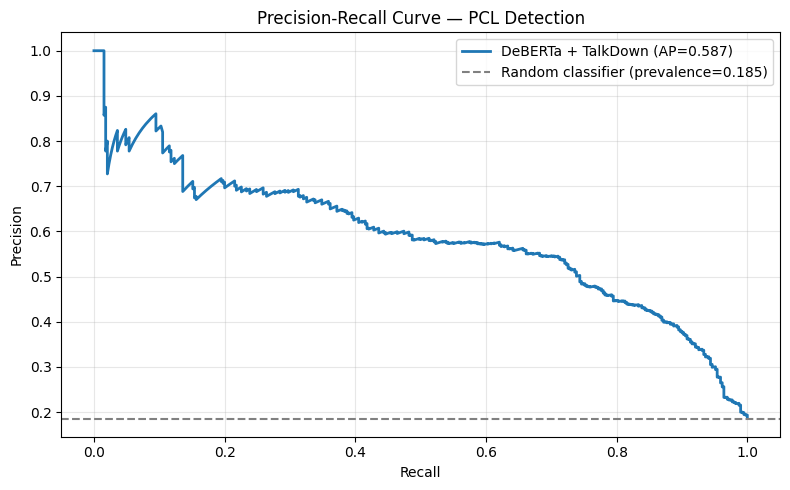

At threshold=0.50: Precision=0.538, Recall=0.713
At threshold=0.39: Precision=?, Recall=?
At threshold=0.39: Precision=0.537, Recall=0.721
Average Precision: 0.5870


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)
ap = average_precision_score(all_labels, all_probs)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, linewidth=2, label=f'DeBERTa + TalkDown (AP={ap:.3f})')
plt.axhline(y=0.185, color='gray', linestyle='--', label='Random classifier (prevalence=0.185)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — PCL Detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/pr_curve.pdf', bbox_inches='tight')
plt.savefig('figures/pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

default_idx = np.argmin(np.abs(thresholds - 0.5))
print(f'At threshold=0.50: Precision={precision[default_idx]:.3f}, Recall={recall[default_idx]:.3f}')
print(f'At threshold={best_thresh:.2f}: Precision=?, Recall=?')
opt_idx = np.argmin(np.abs(thresholds - best_thresh))
print(f'At threshold={best_thresh:.2f}: Precision={precision[opt_idx]:.3f}, Recall={recall[opt_idx]:.3f}')
print(f'Average Precision: {ap:.4f}')